# HW#4 – Multilayer Perceptron Implementation

| | |
|---|---|
| **Student** | **Nabonita Das** |
| **Assignment** | HW#4 – Multilayer Perceptron Implementation |
| **Due date** | October 13, 2026 |
| **Files** | `multilayer_perceptron.py`, `module4.py`, `module4.ipynb` |

---

## Table of Contents
1. Objective
2. Setup
3. Create the network and inspect the architecture
4. Forward propagation on one input
5. Verification by hand calculation
6. Multiple example inputs
7. Batch forward propagation
8. Visualising the results
9. Demonstration network with scaled weights
10. Edge cases
11. Random test and smoke test
12. Conclusion

## 1. Objective

Implement a `MultilayerPerceptron` class with the following network architecture and show the **forward propagation** process from the input layer to the output layer.

| Layer | Neurons | Activation function |
|---|---:|---|
| Input layer | 3 | – |
| Hidden layer 1 | 5 | Sigmoid |
| Hidden layer 2 | 5 | Sigmoid |
| Hidden layer 3 | 2 | Sigmoid |
| Output layer (Layer 4) | 2 | ReLU |

Weights and biases may be chosen freely. This implementation uses reproducible random values (Xavier/Glorot initialisation with `seed=42`) by default, and also accepts custom weights and biases.

### How forward propagation works

For every layer $l$ the network computes two steps:

$$z^{(l)} = a^{(l-1)}\,W^{(l)} + b^{(l)} \qquad\qquad a^{(l)} = f_l\big(z^{(l)}\big)$$

where $a^{(0)}$ is the input vector, $W^{(l)}$ is the weight matrix, $b^{(l)}$ is the bias vector, and $f_l$ is the activation function of layer $l$.

The two activation functions used are:

$$\text{Sigmoid: } \sigma(z) = \frac{1}{1 + e^{-z}} \qquad\qquad \text{ReLU: } \text{ReLU}(z) = \max(0, z)$$

The shapes of the parameters are:

| Layer | $W$ shape | $b$ shape |
|---|---|---|
| 1 | (3, 5) | (5,) |
| 2 | (5, 5) | (5,) |
| 3 | (5, 2) | (2,) |
| 4 | (2, 2) | (2,) |

## 2. Setup

The cell below imports the libraries and the `MultilayerPerceptron` class from `multilayer_perceptron.py`.

> **Note:** It first looks for `multilayer_perceptron.py` in the current folder and its parent folders, so the notebook works no matter which folder VS Code or Jupyter was started from. If the file is not found, a clear message explains what to do.

In [1]:
import sys
from pathlib import Path

# Locate multilayer_perceptron.py so the import works from any starting folder
_here = Path.cwd()
_candidates = [_here, _here / "mlp_project", *_here.parents]
for _p in _candidates:
    if (_p / "multilayer_perceptron.py").exists():
        sys.path.insert(0, str(_p))
        print("Found multilayer_perceptron.py in folder:", _p.name)
        break
else:
    raise FileNotFoundError(
        "multilayer_perceptron.py not found. Put module4.ipynb in the same folder "
        "as multilayer_perceptron.py (or open that folder in VS Code) and run again."
    )

import numpy as np
import matplotlib.pyplot as plt
from multilayer_perceptron import MultilayerPerceptron, sigmoid, relu

np.set_printoptions(precision=5, suppress=True)
print("Student: Nabonita Das")
print("Setup complete.")

Found multilayer_perceptron.py in folder: mlp_project


Student: Nabonita Das
Setup complete.


## 3. Create the network and inspect the architecture

A `MultilayerPerceptron()` created with no arguments uses the required defaults: **3-5-5-2-2** with Sigmoid, Sigmoid, Sigmoid and ReLU.

The summary table lists every layer's neuron count, activation, parameter shapes and parameter count.

In [2]:
mlp = MultilayerPerceptron()      # 3-5-5-2-2, seeded random weights (seed=42)
print(mlp)
print()
print(mlp.summary())

MultilayerPerceptron(architecture=3-5-5-2-2, activations=['sigmoid', 'sigmoid', 'sigmoid', 'relu'], params=68)

Layer        Neurons  Activation   W shape  b shape  Params
-----------------------------------------------------------
Input              3           -         -        -       0
Hidden 1 (L1)       5     sigmoid    (3, 5)     (5,)      20
Hidden 2 (L2)       5     sigmoid    (5, 5)     (5,)      30
Hidden 3 (L3)       2     sigmoid    (5, 2)     (2,)      12
Output (L4)        2        relu    (2, 2)     (2,)       6
-----------------------------------------------------------
Total trainable parameters: 68


### Weight and bias shapes
Each weight matrix connects one layer to the next, so its shape is *(neurons in, neurons out)*.

In [3]:
for i, (W, b) in enumerate(zip(mlp.weights, mlp.biases), start=1):
    print(f"Layer {i}: W{i} shape = {W.shape}, b{i} shape = {b.shape}, activation = {mlp.activation_names[i-1]}")

Layer 1: W1 shape = (3, 5), b1 shape = (5,), activation = sigmoid
Layer 2: W2 shape = (5, 5), b2 shape = (5,), activation = sigmoid
Layer 3: W3 shape = (5, 2), b3 shape = (2,), activation = sigmoid
Layer 4: W4 shape = (2, 2), b4 shape = (2,), activation = relu


### Architecture diagram
Blue = input layer, green = hidden layers (Sigmoid), red = output layer (ReLU). Every neuron is connected to every neuron in the next layer.

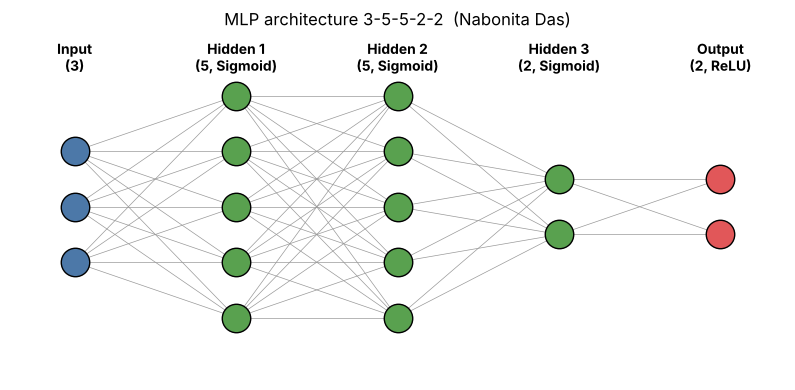

In [4]:
def draw_network(sizes, labels):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    xs = np.linspace(0, 1, len(sizes))
    pos = []
    for x, n in zip(xs, sizes):
        ys = (np.arange(n) - (n - 1) / 2) * 0.16 + 0.5
        pos.append([(x, y) for y in ys])
    for l in range(len(sizes) - 1):
        for (x1, y1) in pos[l]:
            for (x2, y2) in pos[l + 1]:
                ax.plot([x1, x2], [y1, y2], color="#999", lw=0.5, zorder=1)
    colors = ["#4C78A8", "#59A14F", "#59A14F", "#59A14F", "#E15759"]
    for l, pts in enumerate(pos):
        for (x, y) in pts:
            ax.scatter(x, y, s=420, color=colors[l], edgecolor="k", zorder=2)
        ax.text(xs[l], 0.98, labels[l], ha="center", va="top", fontsize=10, fontweight="bold")
    ax.set_xlim(-0.1, 1.1); ax.set_ylim(0.0, 1.0); ax.axis("off")
    ax.set_title("MLP architecture 3-5-5-2-2  (Nabonita Das)")
    plt.show()

draw_network(mlp.layer_sizes,
             ["Input\n(3)", "Hidden 1\n(5, Sigmoid)", "Hidden 2\n(5, Sigmoid)",
              "Hidden 3\n(2, Sigmoid)", "Output\n(2, ReLU)"])

## 4. Forward propagation on one input

We pass the input vector $x = [0.5,\ -1.0,\ 2.0]$ through the network. `mlp.forward(x)` returns the 2 output values.

In [5]:
x = np.array([0.5, -1.0, 2.0])
y = mlp.forward(x)
print("Input :", x)
print("Output:", y)

Input : [ 0.5 -1.   2. ]
Output: [0.21184 0.29902]


### Layer-by-layer trace

With `return_all=True` the network also returns, for every layer, the pre-activation $z$ and the activation $a$. This shows exactly how the signal flows from the input to the output.

In [6]:
out, trace = mlp.forward(x, return_all=True)
print(f"Input a0 = {x}\n")
for step in trace:
    print(f"Layer {step['layer']} ({step['activation']})")
    print(f"   z = {step['z']}")
    print(f"   a = {step['a']}")
print("\nFinal output:", out)

Input a0 = [ 0.5 -1.   2. ]

Layer 1 (sigmoid)
   z = [-1.08867  0.98403  0.2262   1.99866 -0.4352 ]
   a = [0.25187 0.72791 0.55631 0.88066 0.39288]
Layer 2 (sigmoid)
   z = [-0.43365 -0.01629 -0.43447 -0.79838  0.65066]
   a = [0.39325 0.49593 0.39306 0.31037 0.65716]
Layer 3 (sigmoid)
   z = [-0.23395 -0.43835]
   a = [0.44178 0.39213]
Layer 4 (relu)
   z = [0.21184 0.29902]
   a = [0.21184 0.29902]

Final output: [0.21184 0.29902]


## 5. Verification by hand calculation

To confirm the class is correct, we compute **neuron 1 of Layer 1** with plain arithmetic and compare it with the class result:

$$z = x_1 w_{11} + x_2 w_{21} + x_3 w_{31} + b_1 \qquad\qquad a = \sigma(z)$$

In [7]:
W1, b1 = mlp.weights[0], mlp.biases[0]
z_manual = x[0]*W1[0, 0] + x[1]*W1[1, 0] + x[2]*W1[2, 0] + b1[0]
a_manual = 1 / (1 + np.exp(-z_manual))

print(f"z = {x[0]}*{W1[0,0]:.5f} + {x[1]}*{W1[1,0]:.5f} + {x[2]}*{W1[2,0]:.5f} + {b1[0]:.5f} = {z_manual:.5f}")
print(f"a = sigmoid(z) = {a_manual:.5f}")
print(f"Class result for the same neuron: {trace[0]['a'][0]:.5f}")
assert np.isclose(a_manual, trace[0]['a'][0])
print("Match: True")

z = 0.5*0.47451 + -1.0*0.82380 + 2.0*-0.22378 + -0.05455 = -1.08867
a = sigmoid(z) = 0.25187
Class result for the same neuron: 0.25187
Match: True


### Cross-check with an independent implementation

`forward_pure_python` computes the same network using only Python loops (no matrix multiplication). If both implementations agree, the vectorised NumPy version is correct.

In [8]:
y_loop = mlp.forward_pure_python(x.tolist())
print("NumPy      :", y)
print("Pure Python:", np.array(y_loop))
print("Identical  :", np.allclose(y, y_loop))

NumPy      : [0.21184 0.29902]
Pure Python: [0.21184 0.29902]
Identical  : True


## 6. Multiple example inputs

These are the same example inputs that `module4.py` tests. They cover zeros, ones, mixed signs, negatives and very large values.

In [9]:
examples = {
    "all zeros": [0, 0, 0],
    "all ones":  [1, 1, 1],
    "mixed":     [0.5, -1.0, 2.0],
    "negative":  [-3, -2, -1],
    "large":     [50, -50, 100],
}
print(f"{'case':<10} {'input':<22} output")
for name, v in examples.items():
    print(f"{name:<10} {str(v):<22} {mlp.forward(v)}")

case       input                  output
all zeros  [0, 0, 0]              [0.21212 0.30011]
all ones   [1, 1, 1]              [0.20686 0.29293]
mixed      [0.5, -1.0, 2.0]       [0.21184 0.29902]
negative   [-3, -2, -1]           [0.22032 0.31186]
large      [50, -50, 100]         [0.21094 0.30027]


## 7. Batch forward propagation

The network also accepts a 2-D array where each row is one sample. An input of shape *(n_samples, 3)* produces an output of shape *(n_samples, 2)*.

In [10]:
batch = np.array([[0.1, 0.2, 0.3],
                  [1.0, -1.0, 0.5],
                  [-2.0, 2.0, -2.0]])
batch_out = mlp(batch)
print("Input shape :", batch.shape)
print("Output shape:", batch_out.shape)
print(batch_out)

Input shape : (3, 3)
Output shape: (3, 2)
[[0.21107 0.29873]
 [0.21238 0.29956]
 [0.21233 0.30117]]


## 8. Visualising the results

### Activations after each layer
The bars show the activation of every neuron after each layer for the input $[0.5, -1.0, 2.0]$. Sigmoid layers (green) always give values between 0 and 1.

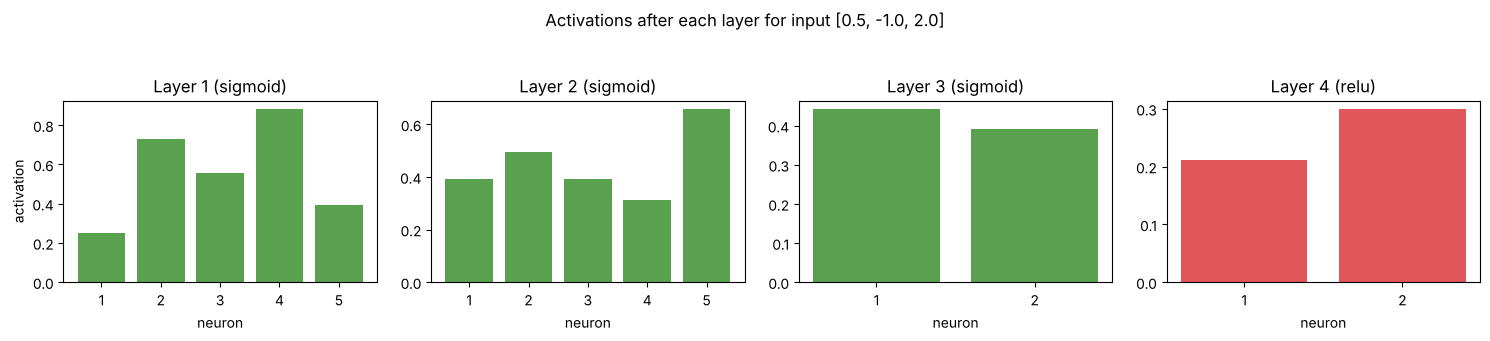

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, step in zip(axes, trace):
    vals = step["a"]
    ax.bar(range(1, len(vals) + 1), vals, color="#59A14F" if step["layer"] < 4 else "#E15759")
    ax.set_title(f"Layer {step['layer']} ({step['activation']})")
    ax.set_xlabel("neuron"); ax.set_xticks(range(1, len(vals) + 1))
    if step["layer"] == 1: ax.set_ylabel("activation")
plt.suptitle("Activations after each layer for input [0.5, -1.0, 2.0]", y=1.05)
plt.tight_layout(); plt.show()

### The two activation functions
Sigmoid squashes any value into (0, 1). ReLU keeps positive values and sets negative values to 0.

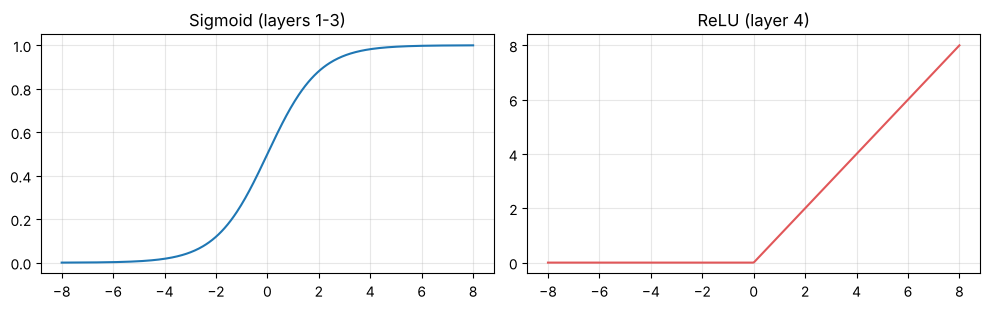

In [12]:
z = np.linspace(-8, 8, 400)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(z, sigmoid(z)); ax[0].set_title("Sigmoid (layers 1-3)"); ax[0].grid(alpha=.3)
ax[1].plot(z, relu(z), color="#E15759"); ax[1].set_title("ReLU (layer 4)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Output response to one input
We sweep the first input from -10 to 10 while keeping the other two fixed, and plot both network outputs.

> **Why is this almost flat?** The default weights are small (Xavier initialisation) and every hidden layer ends in a sigmoid, which squashes values into (0, 1). Together these keep the final outputs in a narrow band. This is expected behaviour, not a bug. Section 9 repeats the experiment with larger, hand-scaled weights so the response becomes clearly visible.

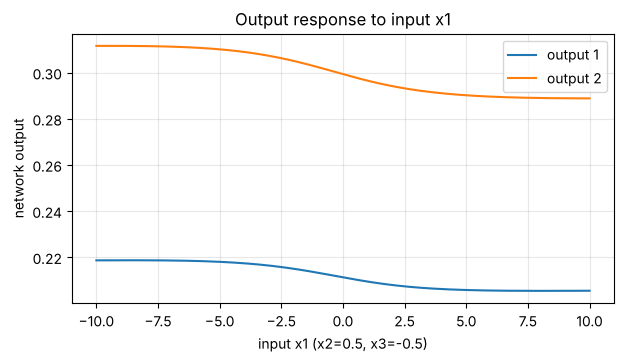

In [13]:
sweep = np.linspace(-10, 10, 200)
X = np.column_stack([sweep, np.full_like(sweep, 0.5), np.full_like(sweep, -0.5)])
Y = mlp(X)
plt.figure(figsize=(7, 3.5))
plt.plot(sweep, Y[:, 0], label="output 1"); plt.plot(sweep, Y[:, 1], label="output 2")
plt.xlabel("input x1 (x2=0.5, x3=-0.5)"); plt.ylabel("network output")
plt.title("Output response to input x1"); plt.legend(); plt.grid(alpha=.3); plt.show()

## 9. Demonstration network with scaled weights

The assignment allows any weights and biases. To make the effect of the input easier to see, this section builds a second network with **larger weights** (standard deviation 3.0, seed 277). The output-layer weights and biases are made non-negative so the ReLU output neurons stay active. The class code is unchanged. Only the parameters passed to the constructor are different.

In [14]:
sizes = MultilayerPerceptron.DEFAULT_LAYER_SIZES
rng_demo = np.random.default_rng(277)
Wd = [rng_demo.normal(0, 3.0, size=(a, b)) for a, b in zip(sizes[:-1], sizes[1:])]
Bd = [rng_demo.normal(0, 0.5, size=b) for b in sizes[1:]]
Wd[-1] = np.abs(Wd[-1]) * 0.6          # keep ReLU output neurons active
Bd[-1] = np.abs(Bd[-1]) * 0.2
demo = MultilayerPerceptron(weights=Wd, biases=Bd)

print(demo)
print("Output for [0.5, -1.0, 2.0]:", demo.forward([0.5, -1.0, 2.0]))
print("Output for [-2.0, 0.0, 1.0]:", demo.forward([-2.0, 0.0, 1.0]))
print("Cross-check (pure Python)  :", np.array(demo.forward_pure_python([0.5, -1.0, 2.0])))

MultilayerPerceptron(architecture=3-5-5-2-2, activations=['sigmoid', 'sigmoid', 'sigmoid', 'relu'], params=68)
Output for [0.5, -1.0, 2.0]: [1.77148 2.87755]
Output for [-2.0, 0.0, 1.0]: [3.3022  4.63348]
Cross-check (pure Python)  : [1.77148 2.87755]


### Output response with scaled weights
The same sweep as before, now on the demonstration network. Both outputs change by several units across the range.

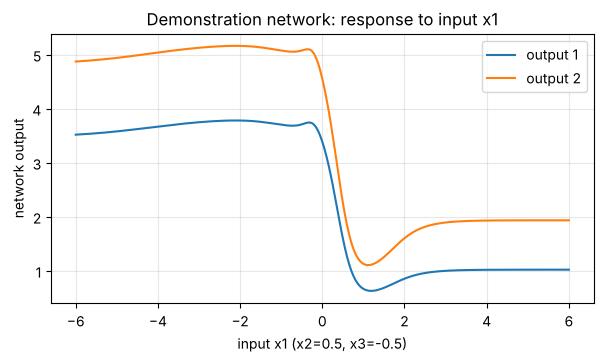

In [15]:
sweep = np.linspace(-6, 6, 241)
X = np.column_stack([sweep, np.full_like(sweep, 0.5), np.full_like(sweep, -0.5)])
Yd = demo(X)
plt.figure(figsize=(7, 3.5))
plt.plot(sweep, Yd[:, 0], label="output 1"); plt.plot(sweep, Yd[:, 1], label="output 2")
plt.xlabel("input x1 (x2=0.5, x3=-0.5)"); plt.ylabel("network output")
plt.title("Demonstration network: response to input x1"); plt.legend(); plt.grid(alpha=.3); plt.show()

### Output surface over two inputs
The heat map shows output 1 as the first two inputs vary over a grid, with the third input fixed at 0.

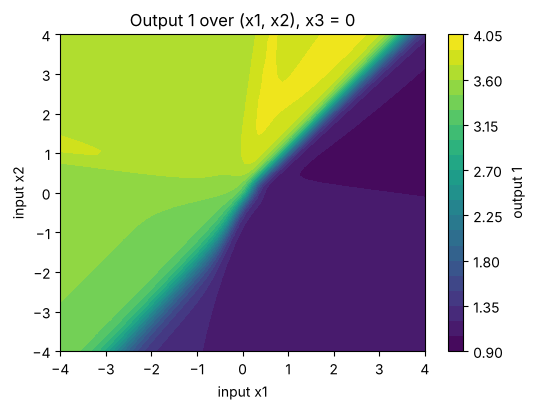

In [16]:
g = np.linspace(-4, 4, 80)
G1, G2 = np.meshgrid(g, g)
grid = np.column_stack([G1.ravel(), G2.ravel(), np.zeros(G1.size)])
Z = demo(grid)[:, 0].reshape(G1.shape)
plt.figure(figsize=(5.5, 4.2))
im = plt.contourf(G1, G2, Z, levels=20, cmap="viridis")
plt.colorbar(im, label="output 1")
plt.xlabel("input x1"); plt.ylabel("input x2"); plt.title("Output 1 over (x1, x2), x3 = 0")
plt.tight_layout(); plt.show()

## 10. Edge cases

- **Huge inputs** must not overflow, because the sigmoid is implemented in a numerically stable way.
- **ReLU can output exactly 0.** With a large negative bias on an output neuron, the output is clamped to 0.
- **Invalid inputs** (wrong size or NaN) are rejected with a clear error message.

In [17]:
with np.errstate(over="raise", invalid="raise", divide="raise"):
    print("Huge inputs  :", mlp.forward([1e6, -1e6, 1e6]))
print("Zero input   :", mlp.forward([0, 0, 0]))

sizes = MultilayerPerceptron.DEFAULT_LAYER_SIZES
W = [np.ones((a, b)) * 0.1 for a, b in zip(sizes[:-1], sizes[1:])]
B = [np.zeros(b) for b in sizes[1:]]
B[-1] = np.array([-5.0, 0.0])           # large negative bias on output neuron 1
custom = MultilayerPerceptron(weights=W, biases=B)
print("ReLU clamps  :", custom.forward([1, 1, 1]), " <- first output is exactly 0")

for bad in ([1, 2], [1, np.nan, 3]):
    try:
        mlp.forward(bad)
    except ValueError as e:
        print(f"Rejected {bad}: {e}")

Huge inputs  : [0.21094 0.30027]
Zero input   : [0.21212 0.30011]
ReLU clamps  : [0.      0.11419]  <- first output is exactly 0
Rejected [1, 2]: Expected 3 input features, got 2.
Rejected [1, nan, 3]: Input contains NaN or infinity.


## 11. Random test and smoke test

**Random test:** 500 different random networks and random inputs (small and very large values). Each result must be finite, non-negative (ReLU output) and identical to the pure-Python implementation.

In [18]:
rng = np.random.default_rng(2026)
n_trials, ok = 500, 0
for _ in range(n_trials):
    net = MultilayerPerceptron(seed=int(rng.integers(0, 10_000)))
    v = rng.normal(scale=10.0 ** rng.integers(-2, 3), size=3)
    o = net.forward(v)
    ok += bool(np.all(np.isfinite(o)) and np.all(o >= 0)
               and np.allclose(o, net.forward_pure_python(v)))
print(f"Random test: {ok}/{n_trials} random networks+inputs passed "
      "(finite, non-negative, NumPy == pure Python)")

Random test: 500/500 random networks+inputs passed (finite, non-negative, NumPy == pure Python)


**Smoke test:** a quick check that the basics work.

In [19]:
checks = {
    "builds with defaults (3-5-5-2-2)": mlp.layer_sizes == (3, 5, 5, 2, 2),
    "forward gives 2 finite values": mlp.forward([1, 2, 3]).shape == (2,),
    "batch shape (10, 2)": mlp(np.zeros((10, 3))).shape == (10, 2),
    "output non-negative (ReLU)": bool(np.all(mlp(rng.normal(size=(50, 3))) >= 0)),
}
for name, passed in checks.items():
    print(("[OK]  " if passed else "[FAIL]"), name)
assert all(checks.values())
print("\nSmoke test passed.")

[OK]   builds with defaults (3-5-5-2-2)
[OK]   forward gives 2 finite values
[OK]   batch shape (10, 2)
[OK]   output non-negative (ReLU)

Smoke test passed.


## 12. Conclusion

- The `MultilayerPerceptron` class implements the required **3-5-5-2-2** architecture, with **Sigmoid** on layers 1-3 and **ReLU** on layer 4 (the output layer).
- Forward propagation was shown step by step, verified by hand for one neuron, and cross-checked against an independent pure-Python implementation.
- The class supports single samples and batches, validates its input, and uses a numerically stable sigmoid.
- A second network with scaled weights shows a clearly visible input-output response, using the same unchanged class.
- Random tests and a smoke test pass, as do the 99 pytest tests in the project.

---

**Submitted by:** Nabonita Das
**Assignment:** HW#4 – Multilayer Perceptron Implementation